In [1]:
import os
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / 'engines').is_dir() and (path / 'models').is_dir():
            return path

    env_root = os.environ.get('FIN_MATH_ROOT')
    if env_root:
        path = Path(env_root).expanduser().resolve()
        if (path / 'engines').is_dir() and (path / 'models').is_dir():
            return path

    candidates = [
        start / 'Fin_Math',
        start / 'fin-math',
        Path.home() / 'Desktop' / 'Fin_Math',
        Path.home() / 'Desktop' / 'fin-math',
        Path.home() / 'Documents' / 'Fin_Math',
        Path.home() / 'Documents' / 'fin-math',
    ]
    for path in candidates:
        if (path / 'engines').is_dir() and (path / 'models').is_dir():
            return path

    raise FileNotFoundError(
        "Could not find repo root containing 'engines' and 'models'. "
        "Set FIN_MATH_ROOT or update the candidates list."
    )

root = _find_repo_root(Path.cwd().resolve())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))


In [2]:
from engines.monte_carlo import MonteCarloPricing
from models.binomial_method import BinomialPricing

In [3]:
# European option pricing: Binomial (CRR) vs plain Monte Carlo
S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.2, 1.0
steps_tree = 1000
paths = 100_000
steps_mc = 1  # European payoff only needs terminal draw

binom = BinomialPricing(S_0=S0, K=K, r=r, sigma=sigma, T=T, steps=steps_tree)
mc = MonteCarloPricing(S_0=S0, X=K, r=r, sigma=sigma, T=T, num_paths=paths, steps=steps_mc, seed=42)

binom_call = binom.european(call=True)
binom_put = binom.european(call=False)
mc_call, mc_call_se = mc.european(call=True, antithetic=False)
mc_put, mc_put_se = mc.european(call=False, antithetic=False)
# Implied payoff variance from SE: var = SE^2 * N
mc_call_payoff_var = (mc_call_se ** 2) * paths
mc_put_payoff_var = (mc_put_se ** 2) * paths
mc_call_est_var = mc_call_se ** 2
mc_put_est_var = mc_put_se ** 2

print(f"Binomial (CRR) call: {binom_call:.4f}")
print(f"MC call: {mc_call:.4f} (SE: {mc_call_se:.4f})")
print(f"MC call payoff var: {mc_call_payoff_var:.6f}")
print(f"MC call estimator var: {mc_call_est_var:.8f}")
print(f"Diff (MC - Binom): {mc_call - binom_call:.4f}")
print()
print(f"Binomial (CRR) put:  {binom_put:.4f}")
print(f"MC put:  {mc_put:.4f} (SE: {mc_put_se:.4f})")
print(f"MC put payoff var:  {mc_put_payoff_var:.6f}")
print(f"MC put estimator var:  {mc_put_est_var:.8f}")
print(f"Diff (MC - Binom): {mc_put - binom_put:.4f}")


Binomial (CRR) call: 10.4486
MC call: 10.4205 (SE: 0.0468)
MC call payoff var: 218.740191
MC call estimator var: 0.00218740
Diff (MC - Binom): -0.0280

Binomial (CRR) put:  5.5715
MC put:  5.6122 (SE: 0.0275)
MC put payoff var:  75.734725
MC put estimator var:  0.00075735
Diff (MC - Binom): 0.0407


In [4]:
# Analytical benchmark (Black-Scholes) on a scenario grid
import math
from itertools import product

def _norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def black_scholes_price(S0: float, K: float, r: float, sigma: float, T: float, *, call: bool) -> float:
    if T <= 0.0 or sigma <= 0.0 or S0 <= 0.0 or K <= 0.0:
        raise ValueError('Inputs must be positive and T>0, sigma>0.')
    d1 = (math.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    if call:
        return S0 * _norm_cdf(d1) - K * math.exp(-r * T) * _norm_cdf(d2)
    return K * math.exp(-r * T) * _norm_cdf(-d2) - S0 * _norm_cdf(-d1)

K = 100.0
r = 0.05
moneyness = [1.0]  # S0 / K
maturities = [0.25, 1.0]
vols = [0.15, 0.25]

paths = 50_000
steps_mc = 1
steps_tree = 1000

rows = []
for m, T, sigma in product(moneyness, maturities, vols):
    S0 = m * K
    for call in (True, False):
        bs = black_scholes_price(S0, K, r, sigma, T, call=call)
        mc = MonteCarloPricing(S_0=S0, X=K, r=r, sigma=sigma, T=T,
                               num_paths=paths, steps=steps_mc, seed=123)
        mc_price, mc_se = mc.european(call=call, antithetic=False)
        mc_payoff_var = (mc_se ** 2) * paths
        mc_est_var = mc_se ** 2
        binom = BinomialPricing(S_0=S0, K=K, r=r, sigma=sigma, T=T, steps=steps_tree)
        binom_price = binom.european(call=call)

        mc_z = (mc_price - bs) / mc_se if mc_se > 0 else float('inf')
        rows.append({
            'S0': S0,
            'K': K,
            'T': T,
            'sigma': sigma,
            'call': call,
            'BS': bs,
            'MC': mc_price,
            'MC_se': mc_se,
            'MC_payoff_var': mc_payoff_var,
            'MC_est_var': mc_est_var,
            'MC_z': mc_z,
            'MC_within_2se': abs(mc_z) <= 2.0,
            'Binom': binom_price,
            'MC_abs_err': abs(mc_price - bs),
            'MC_rel_err': abs(mc_price - bs) / bs,
            'Binom_abs_err': abs(binom_price - bs),
            'Binom_rel_err': abs(binom_price - bs) / bs,
        })

try:
    import pandas as pd
    df = pd.DataFrame(rows)
    pd.set_option('display.precision', 6)
    display(df)
except ImportError:
    headers = ['S0','K','T','sigma','call','BS','MC','MC_se','PayoffVar','EstVar','MC_z','MC_2se','Binom','MC_abs_err','MC_rel_err','Binom_abs_err','Binom_rel_err']
    print(' '.join(f'{h:>12s}' for h in headers))
    for row in rows:
        print(
            f"{row['S0']:12.2f}{row['K']:12.2f}{row['T']:12.2f}{row['sigma']:12.2f}"
            f"{str(row['call']):>12s}{row['BS']:12.6f}{row['MC']:12.6f}{row['MC_se']:12.6f}"
            f"{row['MC_payoff_var']:12.6f}{row['MC_est_var']:12.8f}{row['MC_z']:12.2f}"
            f"{str(row['MC_within_2se']):>12s}{row['Binom']:12.6f}"
            f"{row['MC_abs_err']:12.6f}{row['MC_rel_err']:12.6f}"
            f"{row['Binom_abs_err']:12.6f}{row['Binom_rel_err']:12.6f}"
        )

max_abs_z = max(abs(row['MC_z']) for row in rows)
outside = [row for row in rows if abs(row['MC_z']) > 2.0]
print(f"Max |z|: {max_abs_z:.2f} | outside 2 SE: {len(outside)}/{len(rows)}")


,S0,K,T,sigma,call,BS,MC,MC_se,MC_payoff_var,MC_est_var,MC_z,MC_within_2se,Binom,MC_abs_err,MC_rel_err,Binom_abs_err,Binom_rel_err
0,100.0,100.0,0.25,0.15,True,3.635070,3.646374,0.022357,24.992218,0.000500,0.505634,True,3.634317,0.011305,0.003110,0.000753,0.000207
1,100.0,100.0,0.25,0.15,False,2.392850,2.383346,0.016759,14.044013,0.000281,-0.567087,True,2.392097,0.009504,0.003972,0.000753,0.000315
2,100.0,100.0,0.25,0.25,True,5.598400,5.618217,0.037048,68.626494,0.001373,0.534886,True,5.597156,0.019816,0.003540,0.001244,0.000222
3,100.0,100.0,0.25,0.25,False,4.356180,4.341389,0.028327,40.120540,0.000802,-0.522155,True,4.354936,0.014791,0.003395,0.001244,0.000286
4,100.0,100.0,1.00,0.15,True,8.591658,8.615658,0.049902,124.512535,0.002490,0.480939,True,8.590127,0.024000,0.002793,0.001532,0.000178
5,100.0,100.0,1.00,0.15,False,3.714601,3.697124,0.028079,39.422068,0.000788,-0.622395,True,3.713069,0.017476,0.004705,0.001532,0.000412
6,100.0,100.0,1.00,0.25,True,12.335999,12.379047,0.082880,343.452989,0.006869,0.519403,True,12.333527,0.043048,0.003490,0.002472,0.000200
7,100.0,100.0,1.00,0.25,False,7.458941,7.433327,0.048541,117.811757,0.002356,-0.527677,True,7.456470,0.025614,0.003434,0.002472,0.000331


Max |z|: 0.62 | outside 2 SE: 0/8


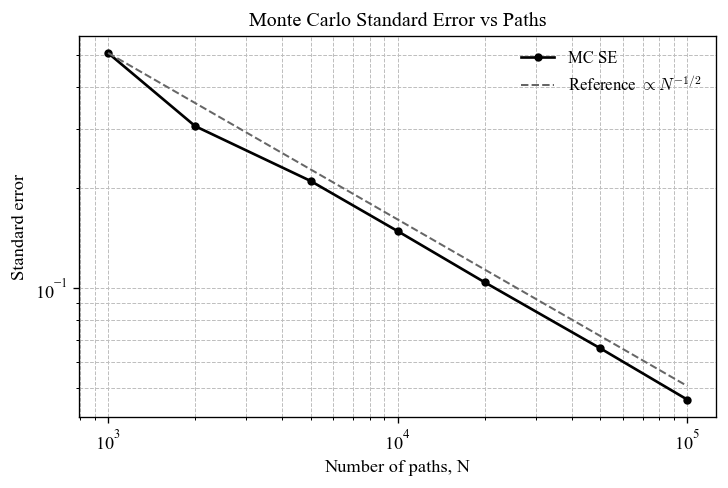

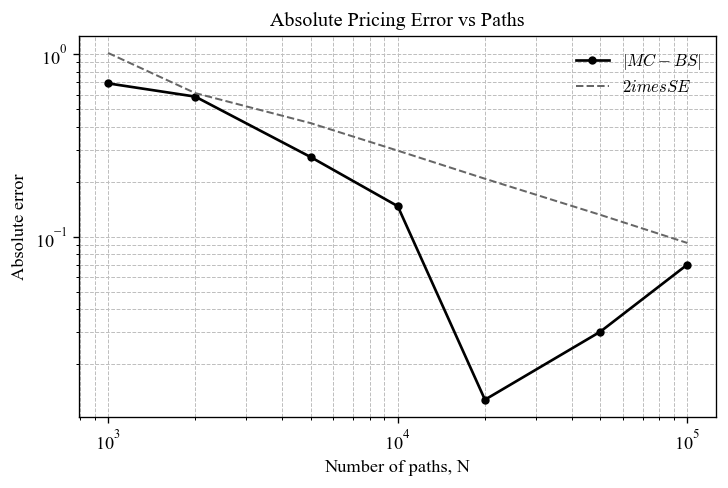

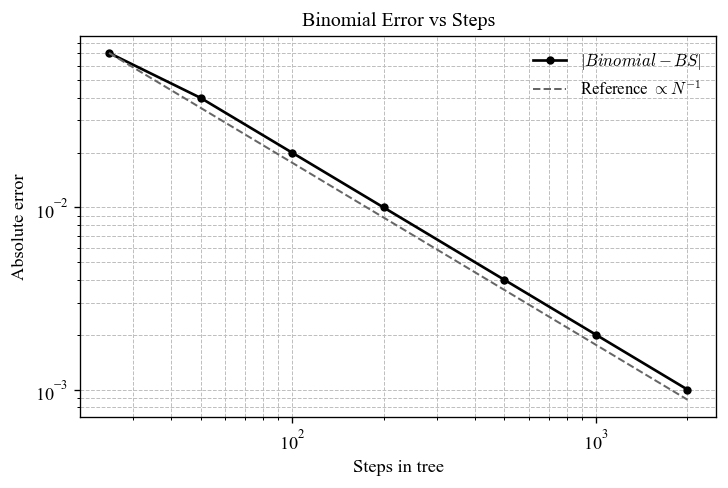

In [5]:
# Monte Carlo convergence: O(1/sqrt(N)) and error trends
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'Palatino', 'Computer Modern Roman'],
    'mathtext.fontset': 'cm',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'axes.linewidth': 0.8,
    'axes.edgecolor': 'black',
    'grid.color': '0.75',
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'figure.dpi': 120,
    'legend.frameon': False,
})

def mc_european_terminal(S0, K, r, sigma, T, *, steps, paths, seed, call=True):
    rng = np.random.default_rng(seed)
    dt = T / steps
    drift = (r - 0.5 * sigma ** 2) * dt
    vol = sigma * np.sqrt(dt)
    log_returns = np.zeros(paths, dtype=float)
    for _ in range(steps):
        log_returns += drift + vol * rng.standard_normal(paths)
    S_T = S0 * np.exp(log_returns)
    if call:
        payoffs = np.maximum(S_T - K, 0.0)
    else:
        payoffs = np.maximum(K - S_T, 0.0)
    discounted = np.exp(-r * T) * payoffs
    return float(np.mean(discounted)), float(np.std(discounted) / np.sqrt(paths))

S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.2, 1.0
bs_call = black_scholes_price(S0, K, r, sigma, T, call=True)

paths_list = [1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000]
mc_prices = []
mc_ses = []
mc_abs_errs = []

for i, n in enumerate(paths_list):
    price, se = mc_european_terminal(S0, K, r, sigma, T,
                                     steps=1, paths=n, seed=1234 + i, call=True)
    mc_prices.append(price)
    mc_ses.append(se)
    mc_abs_errs.append(abs(price - bs_call))

paths_arr = np.array(paths_list, dtype=float)
mc_ses_arr = np.array(mc_ses, dtype=float)
mc_err_arr = np.array(mc_abs_errs, dtype=float)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ref = mc_ses_arr[0] * np.sqrt(paths_arr[0] / paths_arr)
ax.loglog(paths_arr, mc_ses_arr, marker='o', markersize=4,
          linewidth=1.6, color='black', label='MC SE')
ax.loglog(paths_arr, ref, linestyle='--', linewidth=1.2,
          color='0.4', label=r'Reference $\propto N^{-1/2}$')
ax.set_title('Monte Carlo Standard Error vs Paths')
ax.set_xlabel('Number of paths, N')
ax.set_ylabel('Standard error')
ax.grid(True, which='both')
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(paths_arr, mc_err_arr, marker='o', markersize=4,
          linewidth=1.6, color='black', label=r'$|MC - BS|$')
ax.loglog(paths_arr, 2.0 * mc_ses_arr, linestyle='--', linewidth=1.2,
          color='0.4', label=r'$2	imes SE$')
ax.set_title('Absolute Pricing Error vs Paths')
ax.set_xlabel('Number of paths, N')
ax.set_ylabel('Absolute error')
ax.grid(True, which='both')
ax.legend()
fig.tight_layout()
plt.show()

steps_list = [25, 50, 100, 200, 500, 1000, 2000]
binom_errs = []
for steps in steps_list:
    binom = BinomialPricing(S_0=S0, K=K, r=r, sigma=sigma, T=T, steps=steps)
    price = binom.european(call=True)
    binom_errs.append(abs(price - bs_call))

steps_arr = np.array(steps_list, dtype=float)
binom_err_arr = np.array(binom_errs, dtype=float)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ref = binom_err_arr[0] * (steps_arr[0] / steps_arr)
ax.loglog(steps_arr, binom_err_arr, marker='o', markersize=4,
          linewidth=1.6, color='black', label=r'$|Binomial - BS|$')
ax.loglog(steps_arr, ref, linestyle='--', linewidth=1.2,
          color='0.4', label=r'Reference $\propto N^{-1}$')
ax.set_title('Binomial Error vs Steps')
ax.set_xlabel('Steps in tree')
ax.set_ylabel('Absolute error')
ax.grid(True, which='both')
ax.legend()
fig.tight_layout()
plt.show()


In [6]:
# Step-size sensitivity (European MC should be stable across steps)
S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.2, 1.0
steps_list = [1, 52, 252, 1000]
paths = 100_000
seed = 123

bs_call = black_scholes_price(S0, K, r, sigma, T, call=True)
print(f"BS call: {bs_call:.4f}")
for steps_mc in steps_list:
    mc_price, mc_se = mc_european_terminal(S0, K, r, sigma, T,
                                           steps=steps_mc, paths=paths, seed=seed, call=True)
    mc_payoff_var = (mc_se ** 2) * paths
    mc_est_var = mc_se ** 2
    diff = abs(mc_price - bs_call)
    print(f"steps={steps_mc:4d} MC={mc_price:.4f} SE={mc_se:.4f} payoff_var={mc_payoff_var:.6f} est_var={mc_est_var:.8f} |MC-BS|={diff:.4f}")


BS call: 10.4506
steps=   1 MC=10.4573 SE=0.0466 payoff_var=217.482734 est_var=0.00217483 |MC-BS|=0.0068
steps=  52 MC=10.4861 SE=0.0467 payoff_var=217.787180 est_var=0.00217787 |MC-BS|=0.0355
steps= 252 MC=10.5169 SE=0.0468 payoff_var=218.927768 est_var=0.00218928 |MC-BS|=0.0663
steps=1000 MC=10.5580 SE=0.0469 payoff_var=219.923690 est_var=0.00219924 |MC-BS|=0.1074
